# Introduction to Neural Networks

In this activity, you will implement a simple feedforward neural network from scratch using Python. We will use the popular MNIST dataset, which consists of handwritten digits, to train our neural network.

In [71]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [72]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as gz:
        data = np.frombuffer(gz.read(), np.uint8, offset=8)
        return torch.tensor(data, dtype=torch.long)

def get_images(path):
    with gzip.open(path, 'rb') as gz:
        data = np.frombuffer(gz.read(), np.uint8, offset=16)
        data = data.reshape(-1, 1, 28, 28)
        return torch.tensor(data, dtype=torch.float32) / 255.0

In [73]:
# Asegúrate de poner la ruta a los datos
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('../data/mnist')

# Crear los objetos Dataset
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

print(f"Dataset de entrenamiento listo con {len(train_dataset)} muestras.")
print(f"Dataset de validación listo con {len(val_dataset)} muestras.")
print(f"Dataset de prueba listo con {len(test_dataset)} muestras.")

Dataset de entrenamiento listo con 50000 muestras.
Dataset de validación listo con 10000 muestras.
Dataset de prueba listo con 10000 muestras.


In [74]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Ejemplo de cómo obtener un batch
images, labels = next(iter(train_loader))
print(f"Forma del batch de imágenes: {images.shape}") # [BATCH_SIZE, 1, 28, 28]
print(f"Forma del batch de etiquetas: {labels.shape}") # [BATCH_SIZE]

Forma del batch de imágenes: torch.Size([64, 1, 28, 28])
Forma del batch de etiquetas: torch.Size([64])


We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

In [75]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

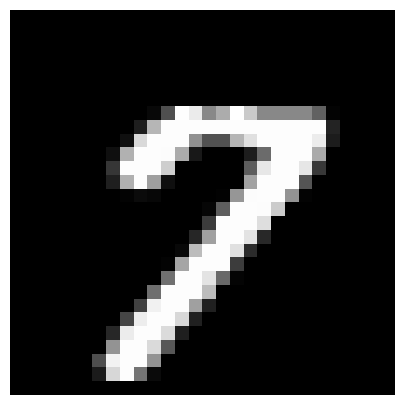

'Label: 7'

In [76]:
random_idx = np.random.randint(0, images.shape[0])

plot_number(images[random_idx])

display(f"Label: {labels[random_idx].squeeze()}") 

## Definir la red neuronal de clasificación multiclase

Necesitamos definir una red mediante una clase que hereda de nn.Module. La arquitectura implementada es una Red Neuronal Feedforward.

In [77]:
class RedNeuronal(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[128], output_size=10):
        super().__init__()
        layers = []
        in_features = input_size
        
        # Agregamos las capas ocultas y ReLU
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
            
        # Capa de salida (sin activación extra, CrossEntropyLoss hace el Softmax)
        layers.append(nn.Linear(in_features, output_size))
        
        # nn.Sequential agrupa las capas para ejecutarlas en orden
        self.red = nn.Sequential(*layers)

    def forward(self, X):
        X = X.view(X.size(0), -1) # Flatten automático
        return self.red(X)

Para medir el rendimiento del modelo en clasificación multiclase, se implementan funciones para calcular:
 - Accuracy: Porcentaje de predicciones correctas totales.
 - Precision, Recall y F1-Score: Métricas esenciales para entender el desempeño detallado por cada clase (dígito).

In [78]:
def accuracy(preds, y):
    correct = (preds == y).sum().item()
    total = y.size(0)
    return correct / total


def recall(preds, y, num_classes=10):
    recalls = []
    for c in range(num_classes):
        # Verdaderos positivos
        tp = ((preds == c) & (y == c)).sum().item()
        # Falsos negativos: el modelo NO predijo 'c', pero la etiqueta real era 'c'
        fn = ((preds != c) & (y == c)).sum().item()
        
        if (tp + fn) == 0:
            recalls.append(0.0)
        else:
            recalls.append(tp / (tp + fn))
            
    return sum(recalls) / num_classes # Promedio Macro
    

def precision(preds, y, num_classes=10):
    precisions = []
    for c in range(num_classes):
        # Verdaderos positivos: el modelo predijo 'c' y la etiqueta real es 'c'
        tp = ((preds == c) & (y == c)).sum().item()
        # Falsos positivos: el modelo predijo 'c' pero la etiqueta real NO es 'c'
        fp = ((preds == c) & (y != c)).sum().item()
        
        if (tp + fp) == 0:
            precisions.append(0.0)
        else:
            precisions.append(tp / (tp + fp))
            
    return sum(precisions) / num_classes # Promedio Macro
    

def f1_score(preds, y):
    _precision = precision(preds, y)
    _recall = recall(preds, y)

    if (_precision + _recall) == 0:
        return 0.0

    return (2 * _precision * _recall) / (_precision + _recall)

El entrenamiento consiste en un proceso iterativo de dos fases principales: Forward Pass y Backward Pass.
 1. Forward Pass: Los datos pasan a través de la red para generar predicciones.
 2. Cálculo de la Pérdida: Se compara la predicción con la etiqueta real usando una función de costo.
 3. Backpropagation: Se calcula el gradiente del error con respecto a cada peso usando la regla de la cadena.
 4. Actualización de Pesos: Un optimizador (como Adam o SGD) ajusta los pesos en la dirección opuesta al gradiente para minimizar el error (Gradient Descent).

In [79]:
def evaluate(model, dataloader, criterion, device):
    """Calcula el Loss y el Accuracy de un dataloader completo."""
    model.eval()
    total_loss = 0.0
    
    
    # Listas para guardar las predicciones y etiquetas de todos los batches
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Paso 1: Forward pass 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            
            # Paso 2: Obtener predicciones del batch
            preds = torch.argmax(outputs, dim=1)
            
            # Paso 3: Guardar en las listas
            all_preds.append(preds)
            all_labels.append(labels)
            

    
    # Concatenamos las listas para tener un solo tensor gigante con todo el dataset
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    avg_loss = total_loss / len(dataloader.dataset)
    
    acc = accuracy(all_preds, all_labels)
    prec = precision(all_preds, all_labels)
    rec = recall(all_preds, all_labels)
    f1 = f1_score(all_preds, all_labels)


    return avg_loss, acc, prec, rec, f1

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    historial = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_prec': [], 'val_rec': [], 'val_f1': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        # Mini-batches
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            
        avg_train_loss = train_loss / len(train_loader.dataset)
        val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader, criterion, device)
        
        historial['train_loss'].append(avg_train_loss)
        historial['val_loss'].append(val_loss)
        historial['val_acc'].append(val_acc)
        historial['val_prec'].append(val_prec)
        historial['val_rec'].append(val_rec)
        historial['val_f1'].append(val_f1)


        print(f"Época {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val Prec: {val_prec*100:.2f}% | Val Rec: {val_rec*100:.2f}% | Val F1: {val_f1*100:.2f}%")
        
    return historial

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}\n")

# Configuraciones para los 3 experimentos
experimentos = [
    {
        "nombre": "Modelo 1 (Base)",
        "hidden_sizes": [128], # 1 capa oculta
        "batch_size": 64,
        "lr": 0.001,
        "epochs": 5,
        "optimizer": "Adam"
    },
    {
        "nombre": "Modelo 2 (Profundo, Batch grande)",
        "hidden_sizes": [256, 128], # 2 capas ocultas
        "batch_size": 256,
        "lr": 0.01,
        "epochs": 10,
        "optimizer": "SGD"
    },
    {
        "nombre": "Modelo 3 (Adam, lr bajo)",
        "hidden_sizes": [128, 64], # 2 capas ocultas
        "batch_size": 32,
        "lr": 0.0005,
        "epochs": 5,
        "optimizer": "Adam"
    }
]

# Función de pérdida para clasificación multiclase
criterion = nn.CrossEntropyLoss()

Entrenando en: cuda



In [81]:
resultados_experimentos = []
mejores_pesos = None
mejor_val_acc = 0.0
mejor_modelo_idx = -1

for idx, config in enumerate(experimentos):
    print(f"{'-'*40}\nIniciando {config['nombre']}")
    print(f"Arquitectura: Ocultas {config['hidden_sizes']}, Batch: {config['batch_size']}, LR: {config['lr']}, Opt: {config['optimizer']}\n{'-'*40}")
    
    # 1. Crear DataLoaders con el Batch Size del experimento
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # 2. Instanciar Modelo
    model = RedNeuronal(hidden_sizes=config['hidden_sizes']).to(device)
    
    # 3. Definir Optimizador
    if config['optimizer'] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)
        
    # 4. Entrenar
    historial = train_model(model, train_loader, val_loader, criterion, optimizer, config['epochs'], device)
    
    # Evaluar si es el mejor modelo (basado en la última época de validación)
    val_acc_final = historial['val_acc'][-1]
    if val_acc_final > mejor_val_acc:
        mejor_val_acc = val_acc_final
        mejor_modelo_idx = idx
        # Guardamos el mejor modelo y sus pesos
        mejor_modelo = model
    
    resultados_experimentos.append(historial)
    print("\n")

----------------------------------------
Iniciando Modelo 1 (Base)
Arquitectura: Ocultas [128], Batch: 64, LR: 0.001, Opt: Adam
----------------------------------------
Época 1/5 | Train Loss: 0.3764 | Val Loss: 0.2072 | Val Acc: 94.09% | Val Prec: 94.16% | Val Rec: 94.02% | Val F1: 94.09%
Época 2/5 | Train Loss: 0.1814 | Val Loss: 0.1469 | Val Acc: 95.90% | Val Prec: 95.89% | Val Rec: 95.89% | Val F1: 95.89%
Época 3/5 | Train Loss: 0.1298 | Val Loss: 0.1144 | Val Acc: 96.68% | Val Prec: 96.68% | Val Rec: 96.65% | Val F1: 96.66%
Época 4/5 | Train Loss: 0.0993 | Val Loss: 0.0989 | Val Acc: 97.21% | Val Prec: 97.21% | Val Rec: 97.17% | Val F1: 97.19%
Época 5/5 | Train Loss: 0.0784 | Val Loss: 0.0885 | Val Acc: 97.51% | Val Prec: 97.50% | Val Rec: 97.48% | Val F1: 97.49%


----------------------------------------
Iniciando Modelo 2 (Profundo, Batch grande)
Arquitectura: Ocultas [256, 128], Batch: 256, LR: 0.01, Opt: SGD
----------------------------------------
Época 1/10 | Train Loss: 1.2

In [82]:
print(f"El mejor modelo fue el Experimento {mejor_modelo_idx + 1}: {experimentos[mejor_modelo_idx]['nombre']}")
print(f"Validation Accuracy Máxima: {mejor_val_acc*100:.2f}%")

El mejor modelo fue el Experimento 1: Modelo 1 (Base)
Validation Accuracy Máxima: 97.51%


## Evaluación Final

Despues de encontrar el mejor modelo, lo evaluamos por la matriz de confusión, accuracy, precision, recall, y f1 score con los datos de pruebas.

In [83]:
def evaluacion_final(_modelo_idx, _model, _criterion, _device):
    # DataLoader para Test (el batch_size no afecta los resultados, solo la velocidad)
    test_loader = DataLoader(test_dataset, batch_size=experimentos[_modelo_idx]['batch_size'], shuffle=False)

    # Evaluamos el modelo campeón
    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(_model, test_loader, _criterion, _device)

    print(f"\n[RESULTADOS FINALES EN TEST CON EL {experimentos[_modelo_idx]['nombre'].upper()}]")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test Precision: {test_prec*100:.2f}%")
    print(f"Test Recall: {test_rec*100:.2f}%")
    print(f"Test F1 Score: {test_f1*100:.2f}%")

    # 1. Asegúrate de estar en modo evaluación y sin calcular gradientes
    _model.eval()
    with torch.no_grad():
        # 2. Mover los datos de prueba al MISMO dispositivo que el modelo
        # x_test es [10000, 1, 28, 28] -> el modelo lo aplanará internamente
        x_test_device = x_test.to(device)
        
        # 3. Obtener predicciones (usa el modelo directamente, no .forward())
        test_scores = _model(x_test_device)
        
        # 4. Pasar a CPU y convertir a NumPy para usar con Seaborn/Matplotlib
        # Importante: argmax debe ser en dim=1 (las clases)
        y_pred = torch.argmax(test_scores, dim=1).cpu().numpy()
        y_true = y_test.numpy()

        # 5. Construir la matriz de confusión
        conf_matrix = np.zeros((10, 10), dtype=int)
        for t, p in zip(y_true, y_pred):
            conf_matrix[t, p] += 1

        # Visualización
        plt.figure(figsize=(10, 8))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=range(10), yticklabels=range(10))
        plt.xlabel('Predicción (Modelo)')
        plt.ylabel('Realidad (Etiqueta)')
        plt.title('Matriz de Confusión: MNIST')
        plt.show()


[RESULTADOS FINALES EN TEST CON EL MODELO 1 (BASE)]
Test Loss: 0.0897
Test Accuracy: 97.31%
Test Precision: 97.31%
Test Recall: 97.29%
Test F1 Score: 97.30%


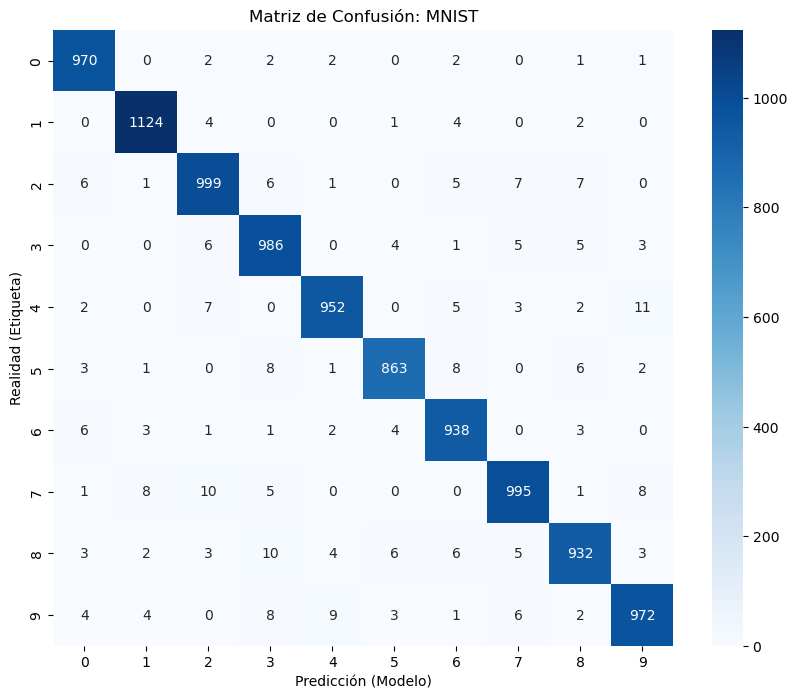

In [84]:
evaluacion_final(mejor_modelo_idx, mejor_modelo, criterion, device)

## Entrenamiento con la tecnica de early stoping

Para prevenir overfitting, modificamos nuestra red neuronal con las técnicas de Dropout y "Early Stop".

In [85]:
class RedNeuronalDropout(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[128], output_size=10, porcentaje=[0.2], porcentaje_output=0.3):
        super().__init__()
        layers = []
        in_features = input_size
        
        # Agregamos las capas ocultas y ReLU
        for h, por in zip(hidden_sizes, porcentaje):
            layers.append(nn.Dropout(p=por))
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
            
        # Capa de salida (sin activación extra, CrossEntropyLoss hace el Softmax)
        layers.append(nn.Dropout(p=porcentaje_output))
        layers.append(nn.Linear(in_features, output_size))
        
        # nn.Sequential agrupa las capas para ejecutarlas en orden
        self.red = nn.Sequential(*layers)

    def forward(self, X):
        X = X.view(X.size(0), -1) # Flatten automático
        return self.red(X)

In [86]:
def train_model_with_early_stop(model, train_loader, val_loader, criterion, optimizer, epochs, device, delta=0.005, patience=3):
    historial = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_prec': [], 'val_rec': [], 'val_f1': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        # Mini-batches
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            
        avg_train_loss = train_loss / len(train_loader.dataset)
        val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader, criterion, device)
        
        historial['train_loss'].append(avg_train_loss)
        historial['val_loss'].append(val_loss)
        historial['val_acc'].append(val_acc)
        historial['val_prec'].append(val_prec)
        historial['val_rec'].append(val_rec)
        historial['val_f1'].append(val_f1)


        print(f"Época {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val Prec: {val_prec*100:.2f}% | Val Rec: {val_rec*100:.2f}% | Val F1: {val_f1*100:.2f}%")
        
        # Logica de Early stopping 
        
        n = len(historial['val_loss']) - 1

        if n >= patience:
            loss_n = historial['val_loss'][n]  # loss (n)
            loss_n_menos_patience = historial['val_loss'][n - patience]

            mejora = loss_n_menos_patience - loss_n

            if np.abs(mejora) < delta and loss_n_menos_patience >= loss_n:
                print(f"Early stopping activado en la época {epoch + 1}.")
                print(f"Estancamiento detectado: la diferencia de loss fue de {abs(mejora):.5f}, menor al delta de {delta}.")
                break

    return historial

In [87]:
# Añadimos los nuevos parámetros para train_model_with_early_stop (weight_decay, porcentaje, output_porcentaje) y subimos la cantidad de épocas
experimentos = [
    {
        "nombre": "Modelo 1 (Base)",
        "porcentaje": [0.2],
        "output_porcentaje": 0.3,
        "hidden_sizes": [128], # 1 capa oculta
        "batch_size": 64,
        "lr": 0.001,
        "epochs": 100,
        "optimizer": "Adam",
        "weight_decay": 1e-4
    },
    {
        "nombre": "Modelo 2 (Profundo, Batch grande)",
        "porcentaje": [0.4, 0.5],
        "output_porcentaje": 0.6,
        "hidden_sizes": [256, 128], # 2 capas ocultas
        "batch_size": 256,
        "lr": 0.01,
        "epochs": 200,
        "optimizer": "SGD",
        "weight_decay": 1e-2
    },
    {
        "nombre": "Modelo 3 (Adam, lr bajo)",
        "porcentaje": [0.1, 0.15],
        "output_porcentaje": 0.2,
        "hidden_sizes": [128, 64], # 2 capas ocultas
        "batch_size": 32,
        "lr": 0.0005,
        "epochs": 50,
        "optimizer": "Adam",
        "weight_decay": 1e-5
    }
]

In [88]:
resultados_experimentos = []
mejores_pesos = None
mejor_val_acc = 0.0
mejor_modelo_idx = -1

for idx, config in enumerate(experimentos):
    print(f"{'-'*40}\nIniciando {config['nombre']}")
    print(f"Arquitectura: Ocultas {config['hidden_sizes']}, Batch: {config['batch_size']}, LR: {config['lr']}, Opt: {config['optimizer']}\n{'-'*40}")
    
    # 1. Crear DataLoaders con el Batch Size del experimento
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # 2. Instanciar Modelo
    model = RedNeuronalDropout(hidden_sizes=config['hidden_sizes'], porcentaje=config['porcentaje'], porcentaje_output=config['output_porcentaje']).to(device)

    # 3. Definir Optimizador
    if config['optimizer'] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=config['weight_decay'])
        
    # 4. Entrenar
    historial = train_model_with_early_stop(model, train_loader, val_loader, criterion, optimizer, config['epochs'], device)
    
    # Evaluar si es el mejor modelo (basado en la última época de validación)
    val_acc_final = historial['val_acc'][-1]
    if val_acc_final > mejor_val_acc:
        mejor_val_acc = val_acc_final
        mejor_modelo_idx = idx
        # Guardamos el mejor modelo y sus pesos
        mejor_modelo = model
    
    resultados_experimentos.append(historial)
    print("\n")

----------------------------------------
Iniciando Modelo 1 (Base)
Arquitectura: Ocultas [128], Batch: 64, LR: 0.001, Opt: Adam
----------------------------------------
Época 1/100 | Train Loss: 0.4690 | Val Loss: 0.2023 | Val Acc: 94.69% | Val Prec: 94.65% | Val Rec: 94.67% | Val F1: 94.66%
Época 2/100 | Train Loss: 0.2478 | Val Loss: 0.1439 | Val Acc: 96.11% | Val Prec: 96.10% | Val Rec: 96.07% | Val F1: 96.09%
Época 3/100 | Train Loss: 0.1997 | Val Loss: 0.1195 | Val Acc: 96.72% | Val Prec: 96.71% | Val Rec: 96.69% | Val F1: 96.70%
Época 4/100 | Train Loss: 0.1735 | Val Loss: 0.1062 | Val Acc: 97.08% | Val Prec: 97.08% | Val Rec: 97.05% | Val F1: 97.07%
Época 5/100 | Train Loss: 0.1565 | Val Loss: 0.0956 | Val Acc: 97.32% | Val Prec: 97.32% | Val Rec: 97.29% | Val F1: 97.31%
Época 6/100 | Train Loss: 0.1441 | Val Loss: 0.0897 | Val Acc: 97.45% | Val Prec: 97.44% | Val Rec: 97.43% | Val F1: 97.43%
Época 7/100 | Train Loss: 0.1326 | Val Loss: 0.0833 | Val Acc: 97.56% | Val Prec: 97.57

In [89]:
print(f"El mejor modelo fue el Experimento {mejor_modelo_idx + 1}: {experimentos[mejor_modelo_idx]['nombre']}")
print(f"Validation Accuracy Máxima: {mejor_val_acc*100:.2f}%")

El mejor modelo fue el Experimento 3: Modelo 3 (Adam, lr bajo)
Validation Accuracy Máxima: 97.83%


## Evaluación Final con Stop Early

Evaluamos el mejor model despues de la funcionalidad de "Early stopping".


[RESULTADOS FINALES EN TEST CON EL MODELO 3 (ADAM, LR BAJO)]
Test Loss: 0.0651
Test Accuracy: 98.12%
Test Precision: 98.12%
Test Recall: 98.10%
Test F1 Score: 98.11%


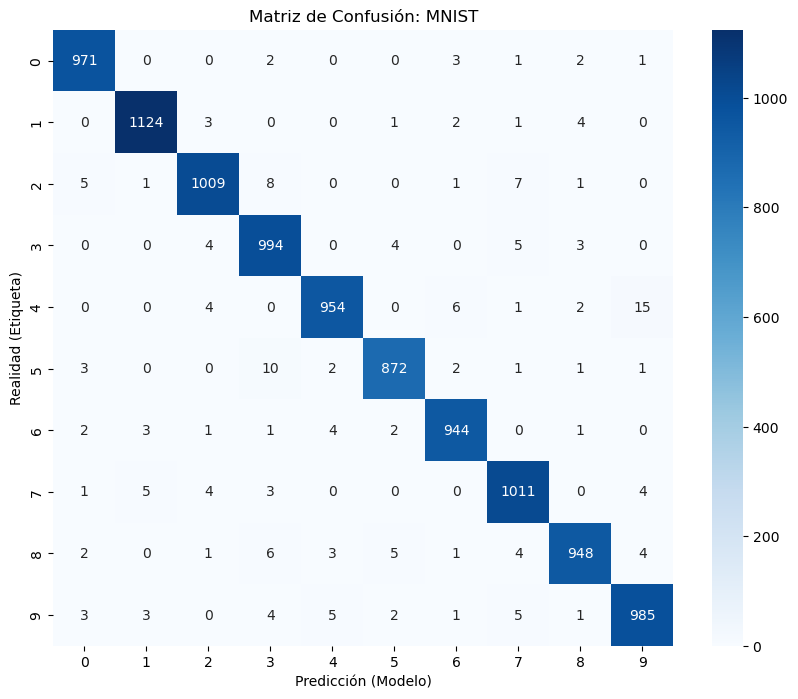

In [90]:
evaluacion_final(mejor_modelo_idx, mejor_modelo, criterion, device)